In [1]:
import torch
from torch import nn
import xgboost as xgb

import math
from matplotlib import pyplot as plt

from func.load_mnist import load_mnist
from func.binarize_embeddings import binarize_embeddings

from Model_QuantizedAE import QuantizedAE

In [2]:
train_dl, validate_dl = load_mnist()

In [3]:

def plot_sample_predictions(samples, labels, predictions):
    n = len(samples)
    grid_size = math.isqrt(n)
    if grid_size * grid_size != n:
        raise ValueError(f"Number of samples must be a perfect square, got {n}")

    fig, axes = plt.subplots(grid_size, grid_size,
                             figsize=(grid_size * 1.8, grid_size * 2.0))

    for idx, ax in enumerate(axes.flat):
        ax.imshow(samples[idx].squeeze().numpy(), cmap="gray", interpolation="nearest")
        title = f"{predictions[idx]} "+("[✔]" if predictions[idx]==labels[idx] else "[✘]")
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [4]:
def load_model(model:nn.Module):
  model_name = type(model).__name__
  state_dict = torch.load(f"data/model_weights/{model_name}.pnn")
  model.load_state_dict(state_dict)
  return model


In [5]:
model = load_model(
  QuantizedAE()
)
model_name = type(model).__name__

embedding_encoder = nn.Sequential(
  model.preprocess,
  model.features,
  nn.Flatten()
)

In [6]:
x , y = next(iter(validate_dl))
x = x[:8*8]
y = y[:8*8]

In [7]:
batch_embeddings = embedding_encoder(x).detach().numpy()
batch_embeddings = binarize_embeddings(batch_embeddings)

In [8]:
# Load model and predict
booster = xgb.Booster()
booster.load_model("data/model_weights/xgb_decision_tree.json")

dmatrix = xgb.DMatrix(batch_embeddings)
preds   = booster.predict(dmatrix).astype(int)

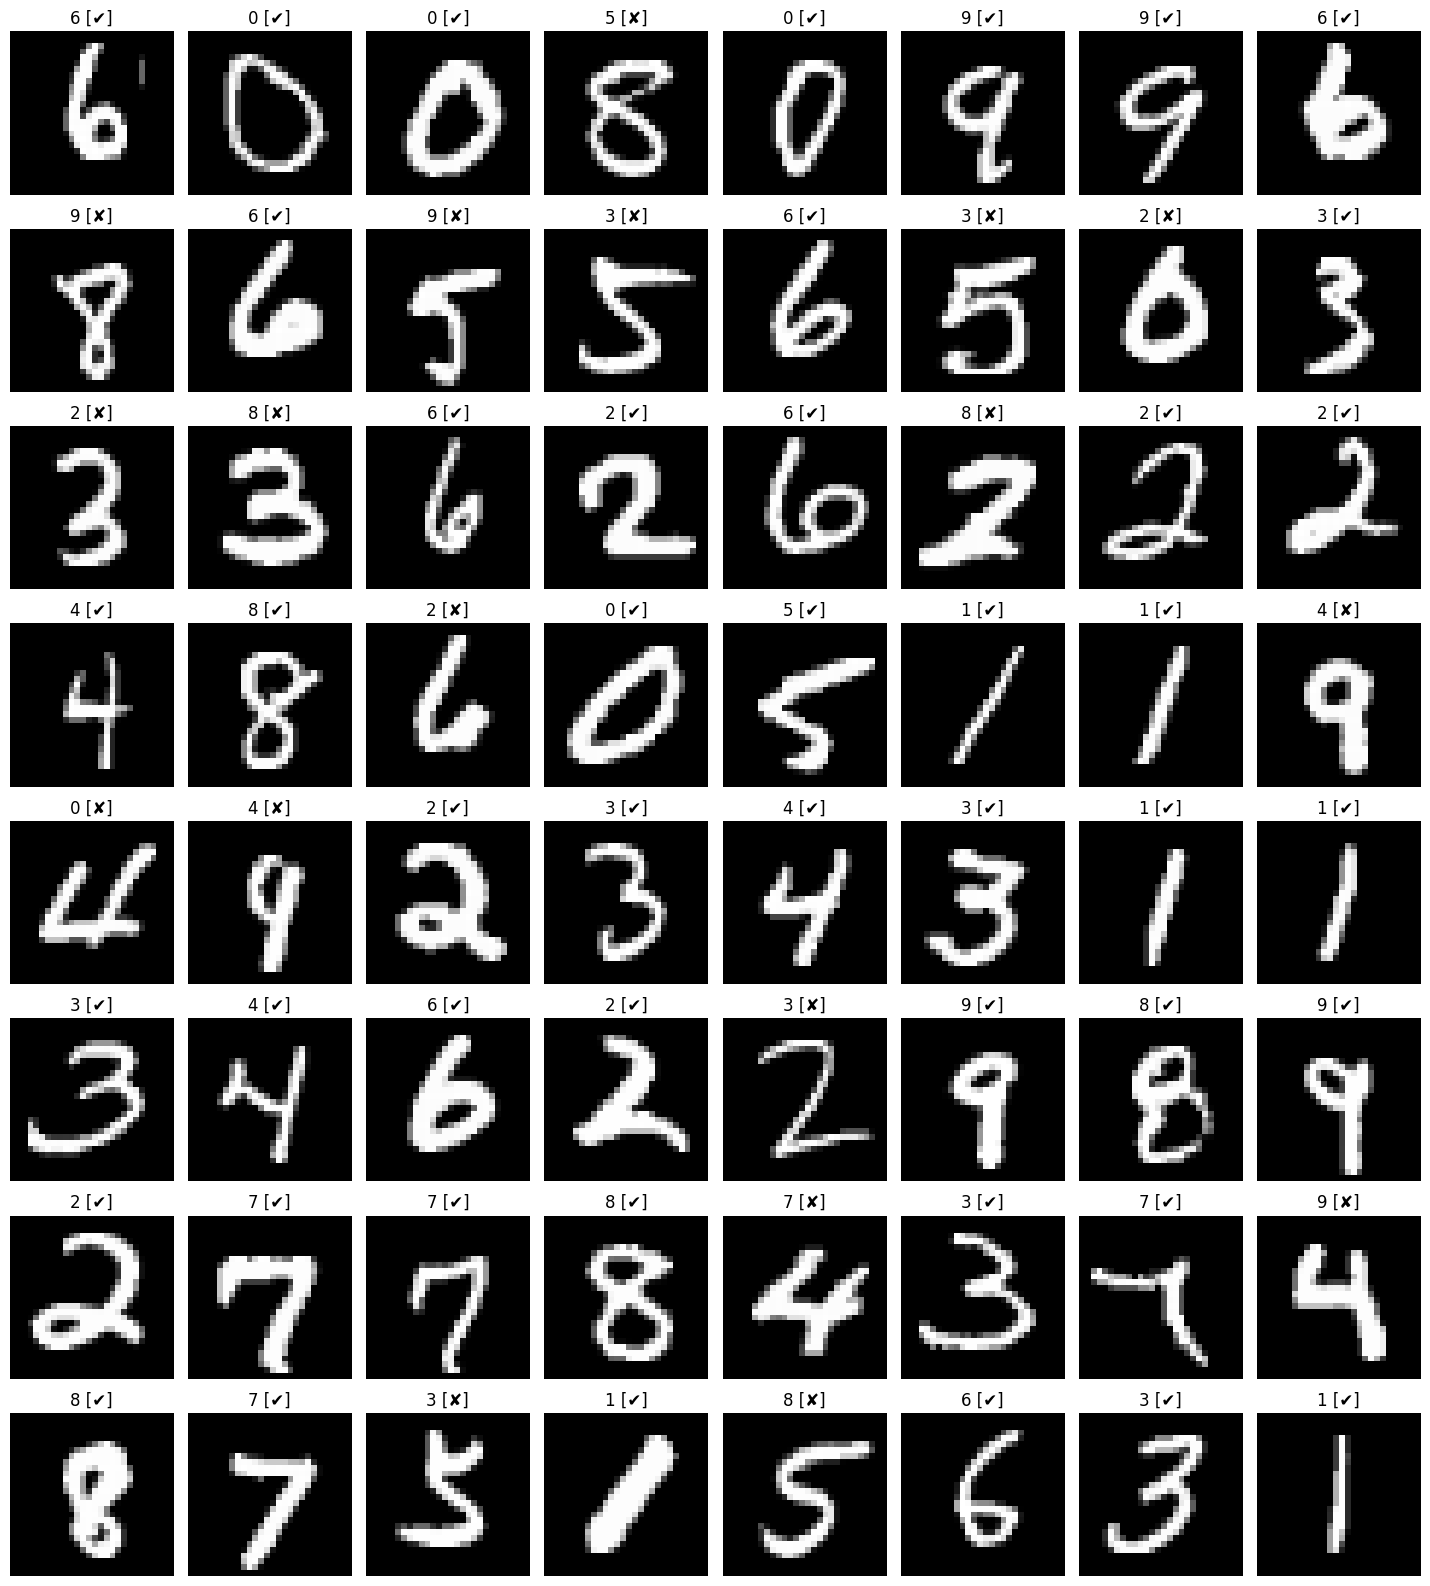

In [9]:
plot_sample_predictions(x,y,preds)

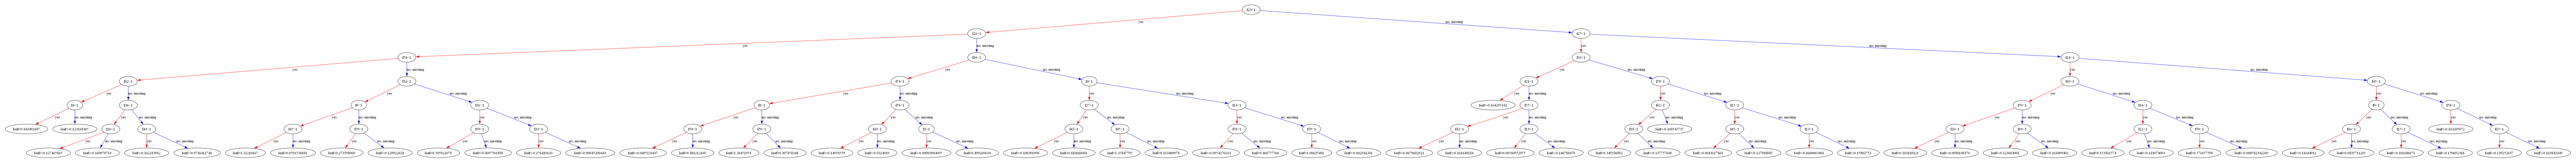

In [13]:
# Now we visualize the tree
fig, ax = plt.subplots(figsize=(80, 40))
xgb.plot_tree(booster, ax=ax)
plt.savefig("data/model_reports/xgb_decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
booster.dump_model('data/model_reports/xgb_decision_dump_trees.txt', with_stats=True)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

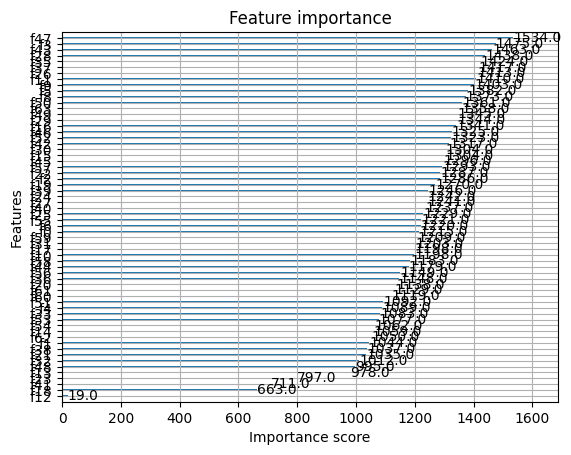

In [20]:
xgb.plot_importance(booster)